<a href="https://colab.research.google.com/github/Srinivas-Manchinasetti/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Credit Card Fraud Detection**

**Aim of the Project**

Given a credit card transaction, predict whether it is fraudulent or legitimate.

Install Libraries

In [ ]:
!pip install imbalanced-learn --quiet

 Import Libraries

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


Upload & Load Dataset

In [ ]:

from google.colab import files

print("Please upload your creditcard.csv file...")
uploaded = files.upload()

df = pd.read_csv('creditcard.csv')
print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape}")

Please upload your creditcard.csv file...


Saving creditcard.csv to creditcard.csv

Dataset loaded successfully!
Shape: (284807, 31)


 Inspect & EDA

=== First 5 Rows ===
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26

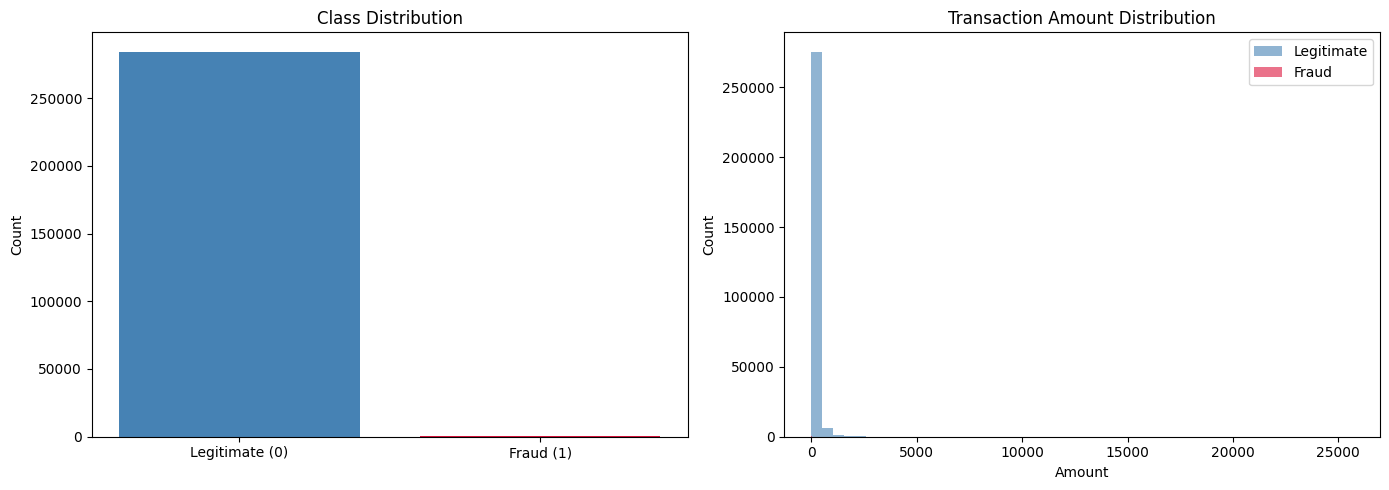

In [ ]:

# Basic info
print("=== First 5 Rows ===")
print(df.head())

print("\n=== Data Types & Null Check ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values found")

print("\n=== Class Distribution ===")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

# Plot 1: Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            df['Class'].value_counts().values,
            color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Plot 2: Transaction amount by class
axes[1].hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.6,
             label='Legitimate', color='steelblue')
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.6,
             label='Fraud', color='crimson')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

Preprocessing

In [ ]:
# Cell 5: Scale 'Amount' and 'Time' columns — V1-V28 are already PCA-scaled by the bank

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time']   = scaler.fit_transform(df[['Time']])

# Drop original unscaled columns
df.drop(columns=['Amount', 'Time'], inplace=True)

print("Preprocessing complete.")
print(f"Dataset shape after preprocessing: {df.shape}")

Preprocessing complete.
Dataset shape after preprocessing: (284807, 31)


Train/Test Split + SMOTE

In [ ]:
# Cell 6: Split data into train/test sets, then apply SMOTE ONLY on training data
# NOTE: SMOTE must never be applied before splitting — that would leak synthetic
#       samples into the test set and give falsely optimistic results

X = df.drop(columns=['Class'])
y = df['Class']

# 80-20 split, stratified to preserve fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE — Training fraud samples: {y_train.sum()}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Training fraud samples: {y_train_sm.sum()}")
print(f"After SMOTE  — Training set size: {X_train_sm.shape[0]}")

Before SMOTE — Training fraud samples: 394
After SMOTE  — Training fraud samples: 227451
After SMOTE  — Training set size: 454902


 Train Models

In [ ]:
# Cell 7: Train Logistic Regression and Decision Tree on the SMOTE-balanced training data

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train_sm, y_train_sm)
print("Decision Tree trained.")

Logistic Regression trained.
Decision Tree trained.


 Evaluate Models


  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9698


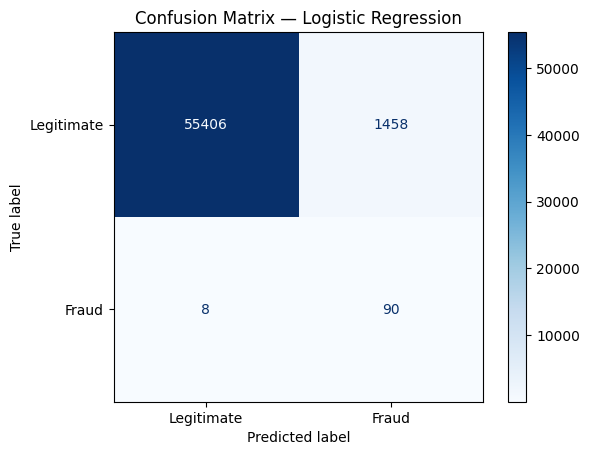


  Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     56864
       Fraud       0.04      0.88      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.92      0.53     56962
weighted avg       1.00      0.96      0.98     56962

ROC-AUC Score: 0.9472


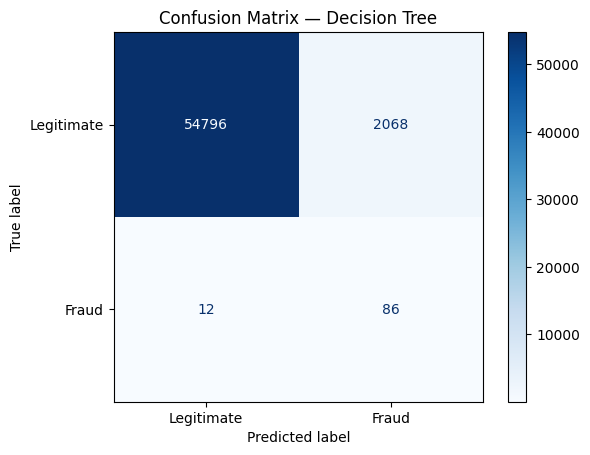

In [ ]:
# Cell 8: Evaluate both models on the untouched test set using multiple metrics

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Legitimate', 'Fraud'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

evaluate_model("Logistic Regression", lr_model, X_test, y_test)
evaluate_model("Decision Tree",       dt_model, X_test, y_test)

 Conclusion

In [ ]:
# Cell 9: Compare both models and print a summary conclusion

from sklearn.metrics import f1_score, recall_score

lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

lr_f1     = f1_score(y_test, lr_pred)
dt_f1     = f1_score(y_test, dt_pred)
lr_recall = recall_score(y_test, lr_pred)
dt_recall = recall_score(y_test, dt_pred)
lr_roc    = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
dt_roc    = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:, 1])

summary = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Decision Tree'],
    'F1 Score':  [round(lr_f1, 4),     round(dt_f1, 4)],
    'Recall':    [round(lr_recall, 4), round(dt_recall, 4)],
    'ROC-AUC':   [round(lr_roc, 4),   round(dt_roc, 4)]
})

print("\n=== Model Comparison Summary ===")
print(summary.to_string(index=False))

best = 'Logistic Regression' if lr_f1 >= dt_f1 else 'Decision Tree'
print(f"\n✅ Best Model: {best}")
print("   Chosen based on highest F1 Score — the right metric for imbalanced fraud data.")


=== Model Comparison Summary ===
              Model  F1 Score  Recall  ROC-AUC
Logistic Regression    0.1094  0.9184   0.9698
      Decision Tree    0.0764  0.8776   0.9472

✅ Best Model: Logistic Regression
   Chosen based on highest F1 Score — the right metric for imbalanced fraud data.
